### Attempt WaveMap

In [1]:
import numpy as np
import os
import sklearn.preprocessing
from umap import umap_ as umap
import wavemap_paper
import matplotlib.pyplot as plt 
from matplotlib import cm
from matplotlib import pyplot as plt
import random
from wavemap_paper.helper_functions import RAND_STATE, set_rand_state
import networkx as nx
import cylouvain
import pandas as pd


# get working directory
os.getcwd()

c:\Users\aitan\miniconda3\envs\wavemap_env\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'd:\\MasterThesis\\code'

In [11]:
### Follow wavemap publication step by step

# Load the data
data_path_test = "d:\\MasterThesis\\data\\wavemap_test_data.npy"
#data_path = "d:\\MasterThesis\\average_waveforms_excit_filtered2.csv"

# Attempt with the test dataset
unnormWFs = np.load(data_path_test)
# unnormWFs = np.loadtxt(data_path, delimiter=',', dtype=float)
print(unnormWFs.shape)
print(type(unnormWFs))
print(unnormWFs[0:13,:])

meanSubWFs = unnormWFs.T - np.mean(unnormWFs,axis=1)
normWFs = sklearn.preprocessing.normalize(meanSubWFs, norm = 'max').T
print(normWFs.shape)
print(type(normWFs))

(625, 48)
<class 'numpy.ndarray'>
[[-6.02061379e-02 -3.15802462e-02 -3.53045965e-02 -3.93422898e-02
  -4.30537829e-02 -4.61219703e-02 -4.79768856e-02 -2.68560999e-02
   5.77957762e-02  8.11163449e-02 -2.62144154e-01 -8.41195906e-01
  -1.09154406e+00 -8.53952363e-01 -3.84829017e-01  2.92150154e-02
   2.77124355e-01  3.91664042e-01  4.34970944e-01  4.38795453e-01
   4.12910374e-01  3.68366242e-01  3.18266639e-01  2.70127908e-01
   2.26055050e-01  1.86482074e-01  1.51888123e-01  1.22388373e-01
   9.61297042e-02  7.28645471e-02  5.29097097e-02  3.52324923e-02
   1.99166104e-02  6.54968557e-03 -4.93237637e-03 -1.54985049e-02
  -2.44930143e-02 -3.22039405e-02 -3.76185988e-02 -4.18740026e-02
  -4.54604700e-02 -4.81581225e-02 -4.97300476e-02 -5.03724635e-02
  -5.04213446e-02 -4.94797033e-02 -4.67081558e-02 -4.25577100e-02]
 [-4.71468665e-02 -6.30341364e-02 -6.69943070e-02 -7.13393435e-02
  -7.73394628e-02 -7.95954628e-02 -7.77206752e-02 -6.37213308e-02
  -1.34603072e-02 -2.46676326e-02 -3.1580

Text(0.5, 1.0, 'Normalized waveforms')

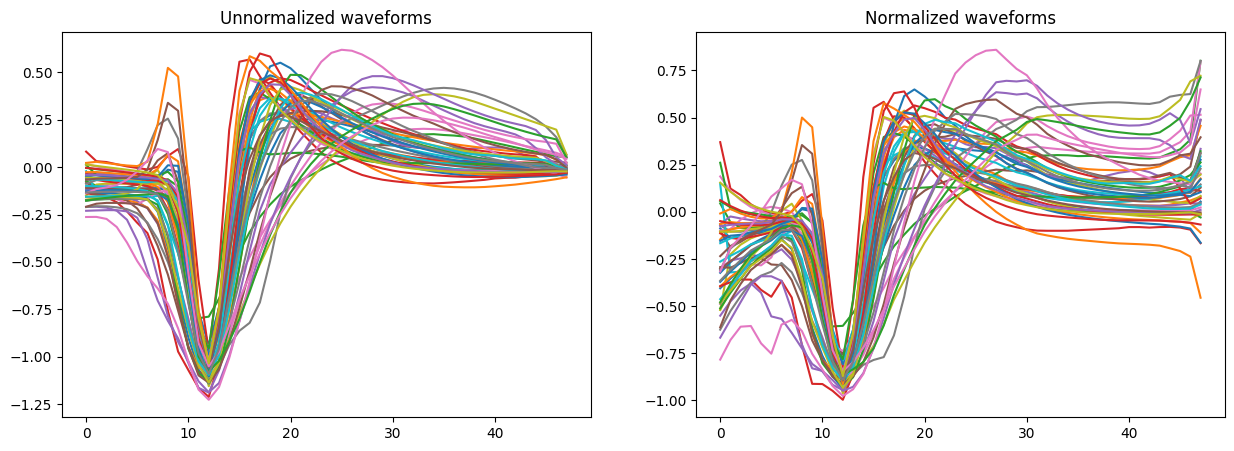

In [12]:
# plot a few waveforms

fig = plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.plot(unnormWFs[1:50].T)
plt.title("Unnormalized waveforms")

plt.subplot(1,2,2)
plt.plot(normWFs[1:50].T)
plt.title("Normalized waveforms")

In [13]:
# Set seed
seed = 42
np.random.seed(seed)    # NumPy
random.seed(seed)       # Python built-in random module
set_rand_state(RAND_STATE)

# TEST
normWFs = unnormWFs     # Mh, the unnormalised one kind of looks better...
### UMAP dimensionality reduction
reducer = umap.UMAP(random_state = RAND_STATE, n_neighbors = 15)
mapper = reducer.fit(normWFs)
G = nx.from_scipy_sparse_array(mapper.graph_)
clustering = cylouvain.best_partition(G, resolution = 2)
clustering_solution = list(clustering.values())


adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


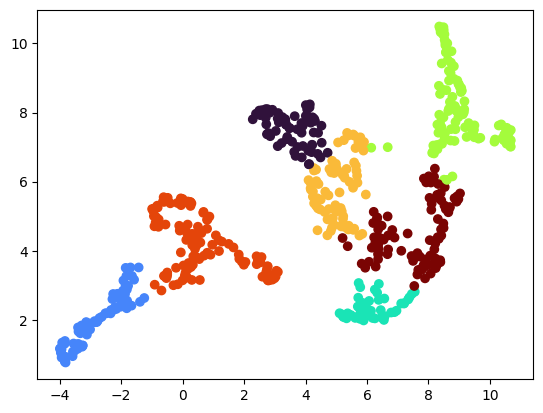

In [14]:
embedding = reducer.fit_transform(normWFs)
umap_df = pd.DataFrame(embedding, columns=('x', 'y'))
umap_df['waveform'] = list(normWFs)
umap_df['cluster_id'] = clustering_solution
cmap = plt.get_cmap("turbo")
colors = cmap(np.linspace(0, 1, len(set(clustering_solution))))
umap_df['cluster_color'] = [colors[i] for i in clustering_solution]
plt.scatter(umap_df['x'].tolist(), umap_df['y'].tolist(),
marker='o', c=umap_df['cluster_id'].tolist(), cmap='turbo')

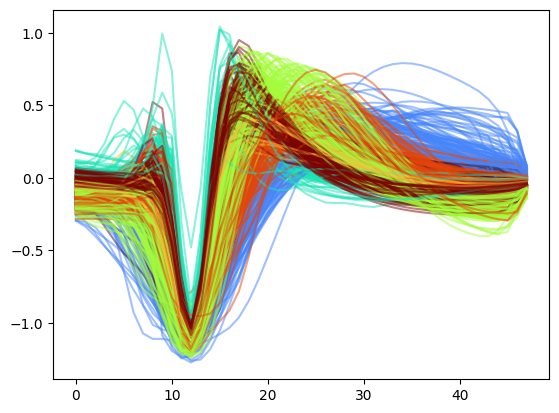

In [15]:
f,arr = plt.subplots(1)
for i,row in enumerate(umap_df['waveform'].tolist()):
    arr.plot(umap_df['waveform'].tolist()[i],c=umap_df['cluster_color'].tolist()[i],alpha=0.5)

-----

### Okay, now try our data

Text(0.5, 1.0, 'Normalized waveforms')

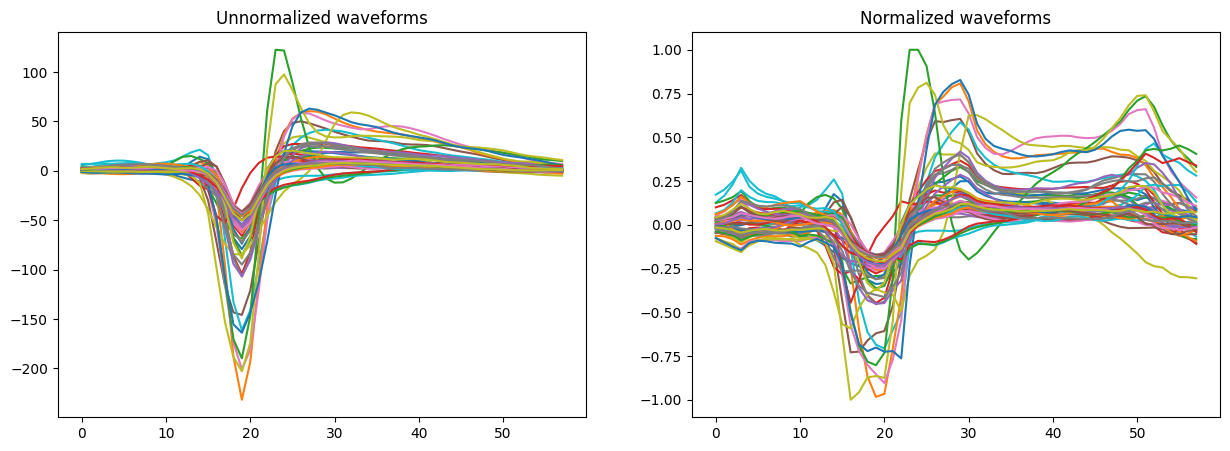

In [28]:
# Load the data
data_path = "d:\\MasterThesis\\analyzer_output\\excit_data\\average_waveforms_excit_filtered3.csv"

unnormWFs = np.loadtxt(data_path, delimiter=',', dtype=float)
meanSubWFs = unnormWFs.T - np.mean(unnormWFs,axis=1)
normWFs = sklearn.preprocessing.normalize(meanSubWFs, norm = 'max').T

# Plot
fig = plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.plot(unnormWFs[1:50].T)
plt.title("Unnormalized waveforms")

plt.subplot(1,2,2)
plt.plot(normWFs[1:50].T)
plt.title("Normalized waveforms")

In [29]:
# Set seed
seed = 42
np.random.seed(seed)    # NumPy
random.seed(seed)       # Python built-in random module
set_rand_state(RAND_STATE)

# TEST
normWFs = unnormWFs     # Mh, the unnormalised one kind of looks better... Maybe need to find a better way to normalise

####### UMAP dimensionality reduction  ########
reducer = umap.UMAP(random_state = RAND_STATE, n_neighbors = 15)    #15
mapper = reducer.fit(normWFs)
G = nx.from_scipy_sparse_array(mapper.graph_)
clustering = cylouvain.best_partition(G, resolution = 1.5)    #2
clustering_solution = list(clustering.values())

embedding = reducer.fit_transform(normWFs)
umap_df = pd.DataFrame(embedding, columns=('x', 'y'))
umap_df['waveform'] = list(normWFs)
umap_df['cluster_id'] = clustering_solution
cmap = plt.get_cmap("turbo")
colors = cmap(np.linspace(0, 1, len(set(clustering_solution))))
umap_df['cluster_color'] = [colors[i] for i in clustering_solution]

adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


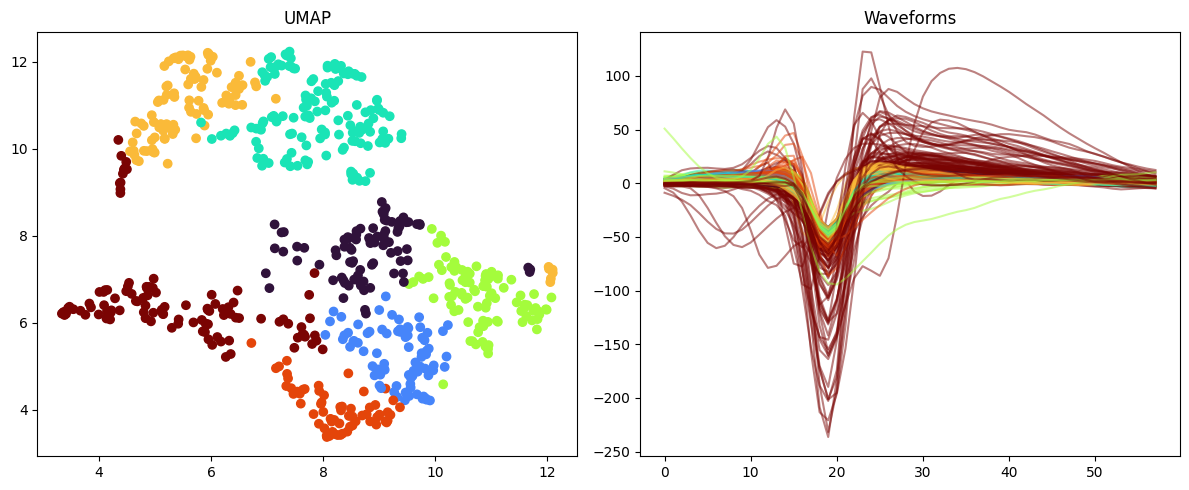

In [30]:
# Plot results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------------------------
# 1) UMAP scatter plot
# -------------------------
sc = axes[0].scatter(
    umap_df['x'],
    umap_df['y'],
    c=umap_df['cluster_id'],
    cmap='turbo',
    marker='o'
)

axes[0].set_title("UMAP")

# -------------------------
# 2) Waveforms
# -------------------------
for i, wf in enumerate(umap_df['waveform']):
    axes[1].plot(
        wf,
        color=umap_df['cluster_color'].iloc[i],
        alpha=0.5
    )

axes[1].set_title("Waveforms")

plt.tight_layout()
plt.show()

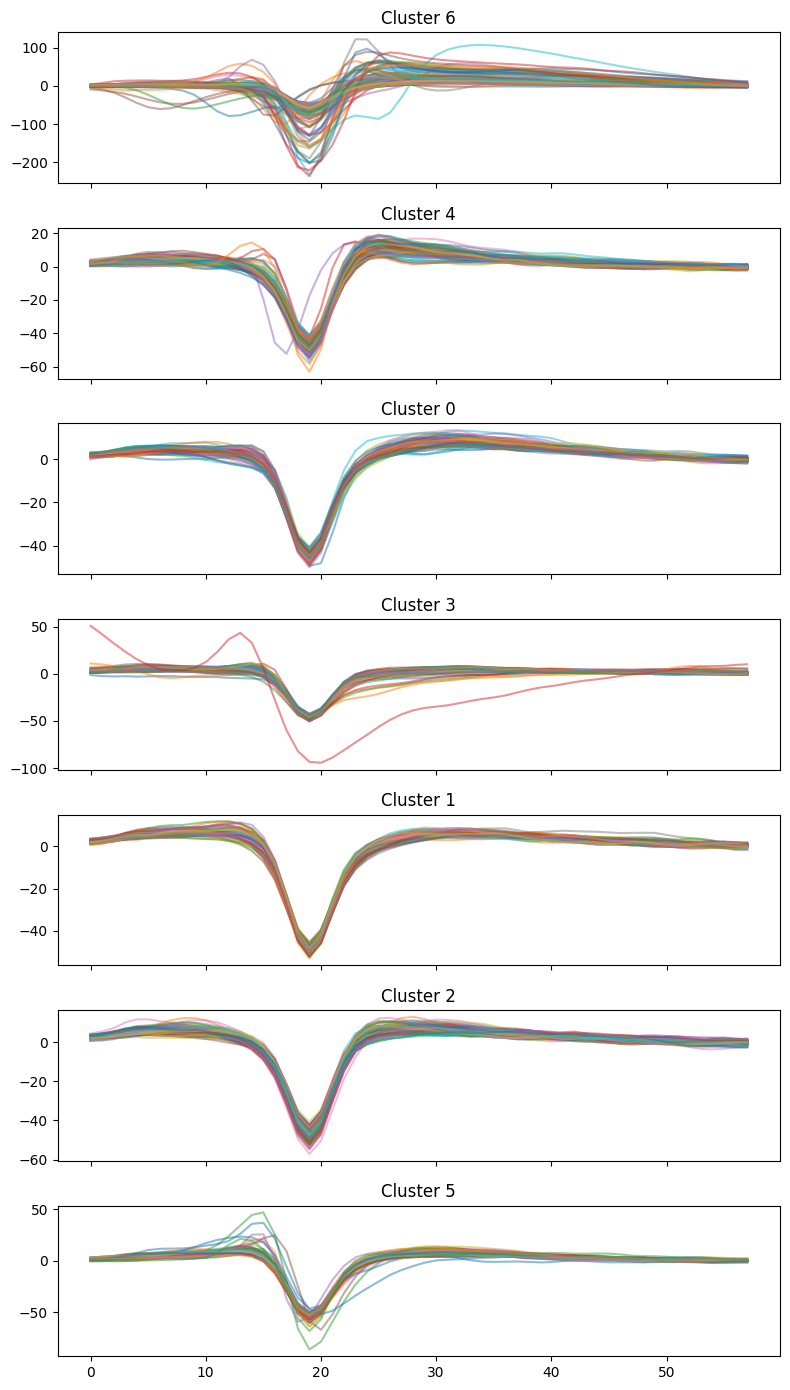

In [31]:
clusters = umap_df['cluster_id'].unique()
n_clusters = len(clusters)

fig, axes = plt.subplots(n_clusters, 1, figsize=(8, 2*n_clusters), sharex=True)

# If only one cluster, axes is not a list → fix that
if n_clusters == 1:
    axes = [axes]

for ax, cluster in zip(axes, clusters):
    cluster_data = umap_df[umap_df['cluster_id'] == cluster]
    
    for wf in cluster_data['waveform']:
        ax.plot(wf, alpha=0.5)

    ax.set_title(f"Cluster {cluster}")

plt.tight_layout()
plt.show()

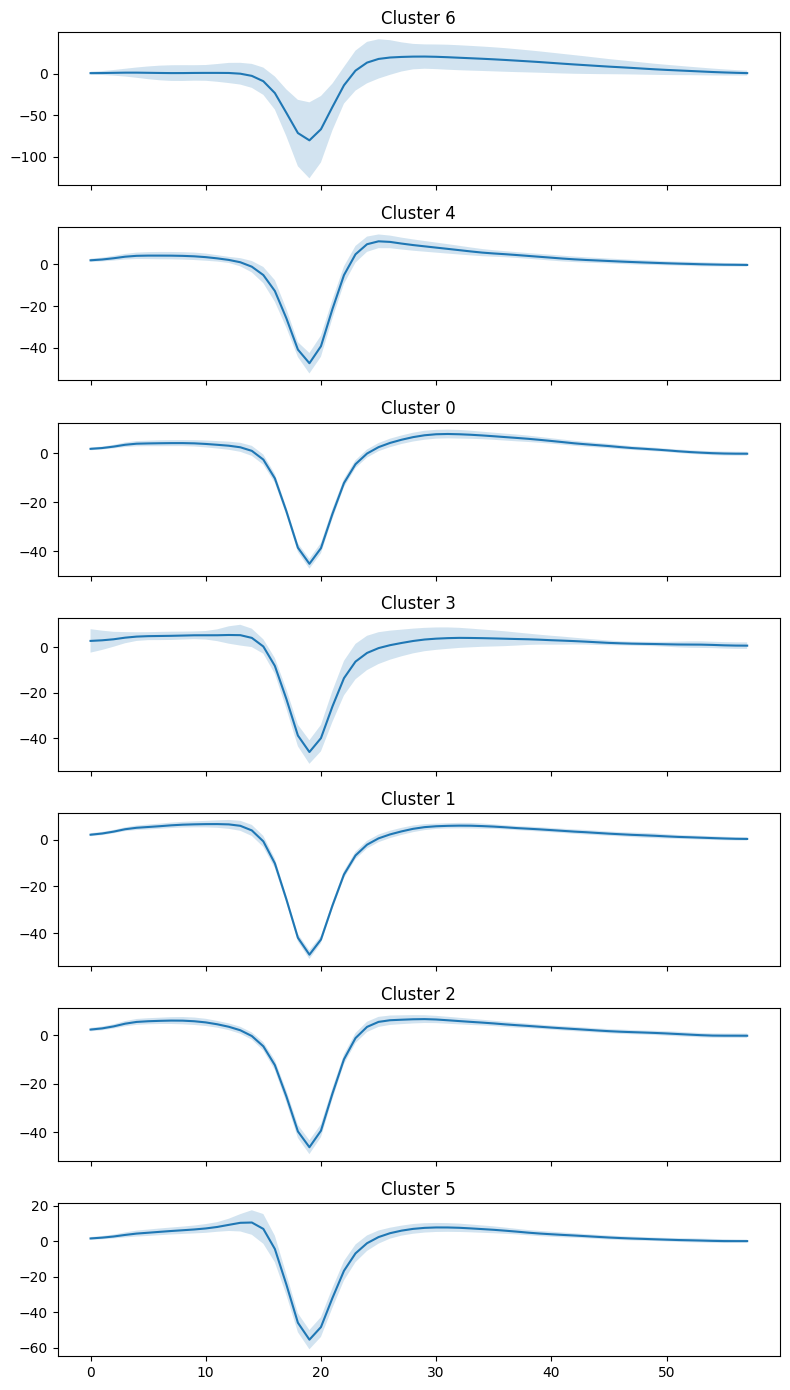

In [32]:
fig, axes = plt.subplots(n_clusters, 1, figsize=(8, 2*n_clusters), sharex=True)

for ax, cluster in zip(axes, clusters):
    cluster_data = umap_df[umap_df['cluster_id'] == cluster]
    
    waves = np.vstack(cluster_data['waveform'])
    
    mean = waves.mean(axis=0)
    std = waves.std(axis=0)
    
    ax.plot(mean)
    ax.fill_between(range(len(mean)), mean-std, mean+std, alpha=0.2)
    
    ax.set_title(f"Cluster {cluster}")

plt.tight_layout()
plt.show()
